In [2]:
from pathlib import Path
csv_path = Path("C:/Users/kaihu/Downloads/HW1_data.csv")
print("File exists:", csv_path.exists())

File exists: True


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [4]:
def load_data(csv_path, random_state=0):
    df = pd.read_csv(csv_path)
    df = df.fillna(0) 
    # Label column
    y_raw = df["Dataset"].astype(int) 
    y = (y_raw == 2).astype(int)
    # Features
    X = df.drop(columns=["Dataset"])
    X = pd.get_dummies(X, drop_first=True)
    # 20% test split
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state, stratify=y
    )
    # 10% validation overall => 0.125 of the remaining 80% as A1 Q4
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.125, random_state=random_state, stratify=y_trainval
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = load_data(csv_path, random_state=0)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print("Train %:", X_train.shape[0] / total)
print("Val %:", X_val.shape[0] / total)
print("Test %:", X_test.shape[0] / total)

Train size: 407
Val size: 59
Test size: 117
Train %: 0.6981132075471698
Val %: 0.10120068610634649
Test %: 0.2006861063464837


In [6]:
def select_rf_model(X_train, y_train, X_val, y_val, X_test, y_test, random_state=0):
    n_list = [10, 20, 50, 100]
    train_acc = []
    val_acc = []

    for n in n_list:
        rf = RandomForestClassifier(
            n_estimators=n,
            bootstrap=True,      
            criterion="gini",   
            random_state=random_state,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        train_acc.append(rf.score(X_train, y_train))
        val_acc.append(rf.score(X_val, y_val))

    # Plot
    plt.figure()
    plt.plot(n_list, train_acc, marker="o", label="Training accuracy")
    plt.plot(n_list, val_acc, marker="o", label="Validation accuracy")
    plt.xlabel("n_estimators")
    plt.ylabel("Accuracy")
    plt.title("Random Forest: Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    # Best by validation accuracy
    best_idx = int(np.argmax(val_acc))
    best_n = n_list[best_idx]

    # Train best model and evaluate on test
    best_rf = RandomForestClassifier(
        n_estimators=best_n,
        bootstrap=True,
        criterion="gini",
        random_state=random_state,
        n_jobs=-1
    )
    best_rf.fit(X_train, y_train)
    test_acc = best_rf.score(X_test, y_test)

    return best_n, test_acc, train_acc, val_acc

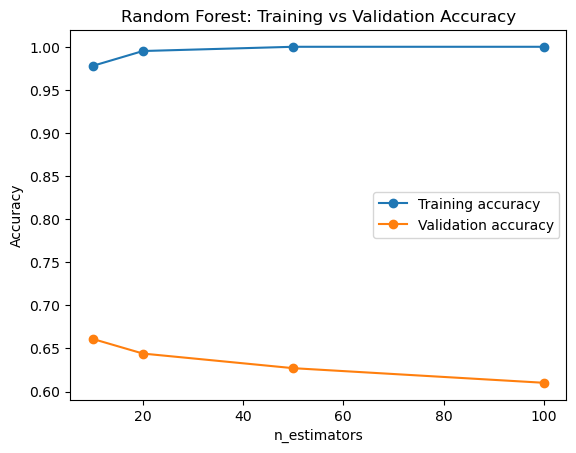

Best n_estimators: 10
Test accuracy (Best Random Forest Model): 0.717948717948718


In [7]:
best_n, test_acc_rf, train_curve, val_curve = select_rf_model(
    X_train, y_train, X_val, y_val, X_test, y_test, random_state=0
)

print("Best n_estimators:", best_n)
print("Test accuracy (Best Random Forest Model):", test_acc_rf)

In [9]:
# Train the best Random Forest model
rf = RandomForestClassifier(n_estimators=10, random_state=0)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
val_acc = rf.score(X_val, y_val)
test_acc = rf.score(X_test, y_test)

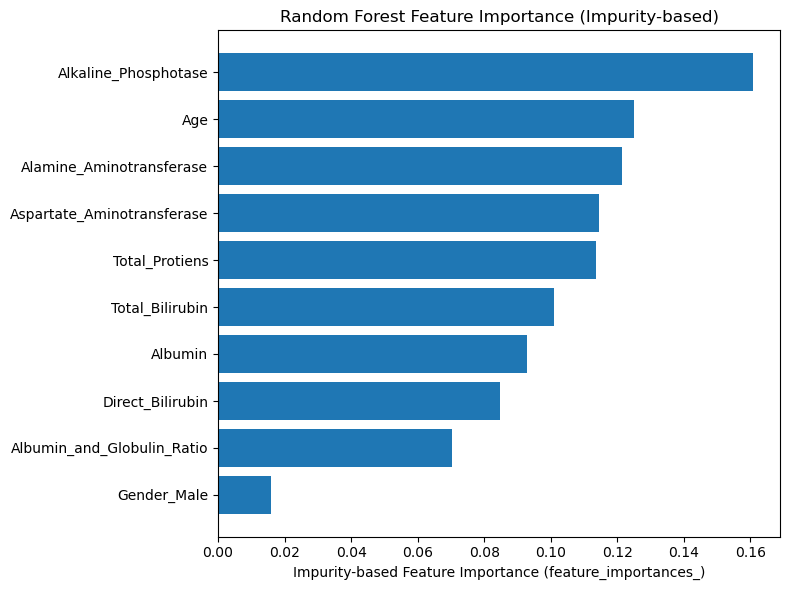

In [18]:
#Impurity-based feature importance: rf.feature_importances_
impurity_importance = rf.feature_importances_
imp_idx = np.argsort(impurity_importance)

plt.figure(figsize=(8, 6))
plt.barh(X_train.columns[imp_idx], impurity_importance[imp_idx])
plt.xlabel("Impurity-based Feature Importance (feature_importances_)")
plt.title("Random Forest Feature Importance (Impurity-based)")
plt.tight_layout()
plt.show()

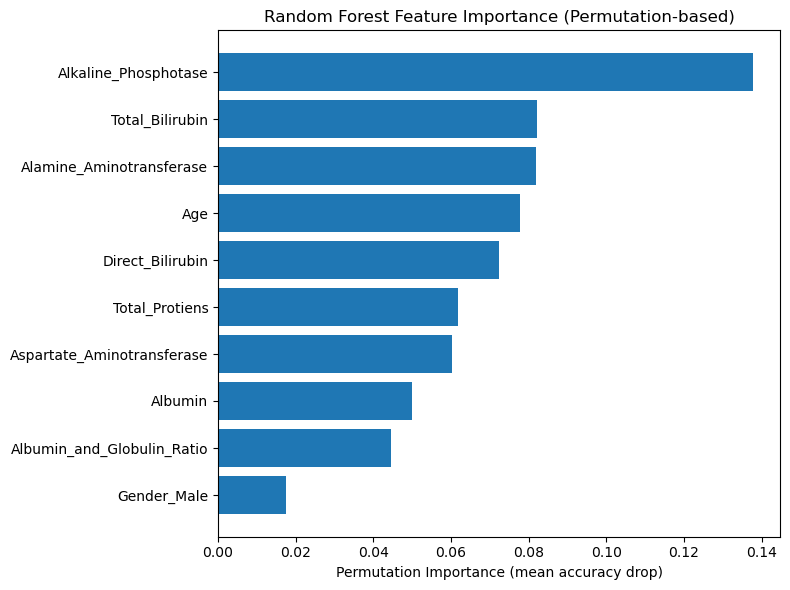

In [19]:
# Permutation-based feature importance on training set
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    rf,
    X_train,
    y_train,
    scoring="accuracy",
    n_repeats=10,
    random_state=0
)

perm_importance = perm.importances_mean
perm_idx = np.argsort(perm_importance) 

plt.figure(figsize=(8, 6))
plt.barh(X_train.columns[perm_idx], perm_importance[perm_idx])
plt.xlabel("Permutation Importance (mean accuracy drop)")
plt.title("Random Forest Feature Importance (Permutation-based)")
plt.tight_layout()
plt.show()

In [21]:
# Compare top-10 (most important features) overlap
k = 10
top_imp = list(X_train.columns[np.argsort(impurity_importance)[::-1][:k]])
top_perm = list(X_train.columns[np.argsort(perm_importance)[::-1][:k]])

overlap = set(top_imp).intersection(set(top_perm))

print("Top-10 (impurity-based):", top_imp)
print("Top-10 (permutation-based):", top_perm)
print(f"Overlap ({len(overlap)}/{k}):", sorted(overlap))

Top-10 (impurity-based): ['Alkaline_Phosphotase', 'Age', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Total_Bilirubin', 'Albumin', 'Direct_Bilirubin', 'Albumin_and_Globulin_Ratio', 'Gender_Male']
Top-10 (permutation-based): ['Alkaline_Phosphotase', 'Total_Bilirubin', 'Alamine_Aminotransferase', 'Age', 'Direct_Bilirubin', 'Total_Protiens', 'Aspartate_Aminotransferase', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Gender_Male']
Overlap (10/10): ['Age', 'Alamine_Aminotransferase', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Alkaline_Phosphotase', 'Aspartate_Aminotransferase', 'Direct_Bilirubin', 'Gender_Male', 'Total_Bilirubin', 'Total_Protiens']
